# Independent Models for Comparing Attended vs Unattended Inputs

This notebook implements an approach that trains separate identical models on each condition:
- Model 1: Trained on LL (left input when attending left) → predicts left attention output
- Model 2: Trained on RL (right input when attending left) → predicts left attention output
- Model 3: Trained on RR (right input when attending right) → predicts right attention output
- Model 4: Trained on LR (left input when attending right) → predicts right attention output

The goal is to test whether models trained on attended inputs (Models 1 and 3) perform better than those trained on unattended inputs (Models 2 and 4) when predicting the same target.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import pickle
from IPython.display import clear_output
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats

from torch.utils.data import DataLoader, TensorDataset
from scipy.ndimage import gaussian_filter1d

# Import models from independent_models.py
from independent_models import (
    BidirectionalLSTM,
    TCN,
    CNNLSTMHybrid,
    SimpleAvgMLP
)

## Data Collection and Preprocessing

The following cell collates the data from each dataset, and zscores within the dataset. Critically, we preprocess before splitting by attention condition.

In [2]:
file_numbers = [1, 2, 4, 8, 14, 15, 20, 23]

def smooth_with_gaussian(data, sigma=2):
    return gaussian_filter1d(data, sigma=sigma, axis=1)  # Gaussian filter along the time axis

def preprocess(data):   # This will receive (trials, time, neurons). Therefore mean across trials. 
    data_z = np.zeros_like(data)
    mean = np.mean(data, axis = 0)
    std = np.std(data, axis = 0)
   
    std[std == 0] = 1  # Avoid division by zero by setting std to 1 where it is 0
    data_z = (data - mean) / std
    return data_z

def get_data(file_number):
    file_path = f'C:/Users/joshu/PartIIIProject/RSNNdale_attention_{file_number}_attention_test'
    data = pickle.load(open(file_path, 'rb'))

    label_left = data['label_left'][0]
    label_right = data['label_right'][0]  # For class of input
    attend_01 = data['attend'][0]
    omitted = data['omit'][0]
    relevant = np.where(omitted == 0)[0]

    left = data['SP'][0][0][relevant, 100:350, :]
    right = data['SP'][0][1][relevant, 100:350, :]
    att = data['SP'][0][2][relevant, 100:350, :]

    num_trials, num_samples, num_neurons = left.shape
    num_neurons_attention = 80

    for j in range(0, num_trials):
        for i in range(0, num_neurons):
            count_left = np.count_nonzero(left[j, :, i] == 1)
            if count_left > 0:
                left[j, :, i] /= count_left
            count_right = np.count_nonzero(right[j, :, i] == 1)
            if count_right > 0:
                right[j, :, i] /= count_right

        for i in range(0, num_neurons_attention):
            count_attention = np.count_nonzero(att[j, :, i] == 1)
            if count_attention > 0:
                att[j, :, i] /= count_attention

    att = np.sum(att, axis=2)  # Return a single time series for the output

    left = preprocess(left)
    right = preprocess(right)
    att = preprocess(att)
   
    # Can now split into left and right attentional modality
    left_indices_agg = np.where((omitted == 0) & (attend_01 == 0) & (label_left != label_right))[0]  # Indices of agg where left
    _, left_indices, _ = np.intersect1d(relevant, left_indices_agg, return_indices = True)   # Indices for relevant processed data where attention left
    right_indices_agg = np.where((omitted == 0) & (attend_01 == 1) & (label_left != label_right))[0]
    _, right_indices, _ = np.intersect1d(relevant, right_indices_agg, return_indices = True)

    # Splitting left and right
    left_attleft = smooth_with_gaussian(left[left_indices], sigma = 2)  # Axis 1 will smooth all of these across time
    right_attleft = smooth_with_gaussian(right[left_indices], sigma = 2)
    att_attleft = smooth_with_gaussian(att[left_indices], sigma = 2)

    left_attright = smooth_with_gaussian(left[right_indices], sigma = 2)
    right_attright = smooth_with_gaussian(right[right_indices], sigma = 2)
    att_attright = smooth_with_gaussian(att[right_indices], sigma = 2)

    print('loaded dataset', file_number)

    return left_attleft, left_attright, right_attleft, right_attright, att_attleft, att_attright
# E.g. dataset 1 gives left_attleft of shape (469 trials, 500 time points, 160 spikes)
    
def collect_data(file_numbers):
    l_al, l_ar, r_al, r_ar, a_al, a_ar = [], [], [], [], [], []
    for file_number in file_numbers:
        left_attleft, left_attright, right_attleft, right_attright, att_attleft, att_attright = get_data(file_number)
        l_al.append(left_attleft)
        l_ar.append(left_attright)
        r_al.append(right_attleft)
        r_ar.append(right_attright)
        a_al.append(att_attleft)
        a_ar.append(att_attright)
       
    return l_al, l_ar, r_al, r_ar, a_al, a_ar  # (trials, 250, 160)

In [3]:
# Collect the data
l_al, l_ar, r_al, r_ar, a_al, a_ar = collect_data(file_numbers)

loaded dataset 1
loaded dataset 2
loaded dataset 4
loaded dataset 8
loaded dataset 14
loaded dataset 15
loaded dataset 20
loaded dataset 23


## Data Preparation Functions

These functions prepare the data for each of the four independent models.

In [4]:
def normalize_data(x_train, x_val, x_test, y_train, y_val, y_test):
    """Normalize input and target data and convert to PyTorch tensors."""
    # Check for NaN values
    if np.isnan(x_train).any() or np.isnan(y_train).any():
        raise ValueError("Data contains NaN values after normalization.")
    
    # Convert to PyTorch tensors
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
    
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
    
    return x_train_tensor, x_val_tensor, x_test_tensor, y_train_tensor, y_val_tensor, y_test_tensor

def visualize_sample_data(y_train, title="Sample Training Data"):
    """Visualize sample target data."""
    plt.figure(figsize=(10, 6))
    
    # Plot first sample
    plt.subplot(3, 1, 1)
    plt.plot(y_train[0, :], label='Sample 1')
    plt.title(f"{title} - Sample 1")
    plt.grid(True)
    
    # Plot another sample
    plt.subplot(3, 1, 2)
    plt.plot(y_train[10, :], label='Sample 10')
    plt.title(f"{title} - Sample 10")
    plt.grid(True)
    
    # Plot mean
    plt.subplot(3, 1, 3)
    plt.plot(np.mean(y_train, axis=0), label='Mean')
    plt.title(f"{title} - Mean")
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def prepare_dataset(inputs, targets, batch_size=32, random_state=42):
    """Prepare a dataset for a single condition."""
    # Concatenate data from all files
    x_data = np.concatenate([inputs[i] for i in range(len(inputs))], axis=0)
    y_data = np.concatenate([targets[i] for i in range(len(targets))], axis=0)
    
    print(f"Data shape: x={x_data.shape}, y={y_data.shape}")
    
    # Split into train, validation, and test sets
    x_train, x_temp, y_train, y_temp = train_test_split(
        x_data, y_data, test_size=0.3, random_state=random_state
    )
    
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp, test_size=0.5, random_state=random_state
    )
    
    # Normalize and convert to tensors
    x_train_tensor, x_val_tensor, x_test_tensor, y_train_tensor, y_val_tensor, y_test_tensor = normalize_data(
        x_train, x_val, x_test, y_train, y_val, y_test
    )
    
    # Visualize sample data
    visualize_sample_data(y_train)
    
    # Create datasets
    train_ds = TensorDataset(x_train_tensor, y_train_tensor)
    val_ds = TensorDataset(x_val_tensor, y_val_tensor)
    test_ds = TensorDataset(x_test_tensor, y_test_tensor)
    
    # Create dataloaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=True)
    
    return {
        'train_loader': train_loader,
        'val_loader': val_loader,
        'test_loader': test_loader,
        'x_train': x_train,
        'x_val': x_val,
        'x_test': x_test,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test
    }

def prepare_all_datasets(l_al, l_ar, r_al, r_ar, a_al, a_ar, batch_size=32):
    """Prepare datasets for all four conditions."""
    print("Preparing LL dataset (left input, left attention)...")
    ll_dataset = prepare_dataset(l_al, a_al, batch_size=batch_size, random_state=42)
    
    print("\nPreparing RL dataset (right input, left attention)...")
    rl_dataset = prepare_dataset(r_al, a_al, batch_size=batch_size, random_state=42)
    
    print("\nPreparing RR dataset (right input, right attention)...")
    rr_dataset = prepare_dataset(r_ar, a_ar, batch_size=batch_size, random_state=42)
    
    print("\nPreparing LR dataset (left input, right attention)...")
    lr_dataset = prepare_dataset(l_ar, a_ar, batch_size=batch_size, random_state=42)
    
    return {
        'll': ll_dataset,  # Left input, Left attention (attended/in)
        'rl': rl_dataset,  # Right input, Left attention (unattended/out)
        'rr': rr_dataset,  # Right input, Right attention (attended/in)
        'lr': lr_dataset   # Left input, Right attention (unattended/out)
    }

Preparing LL dataset (left input, left attention)...
Data shape: x=(3785, 250, 160), y=(3785, 250)


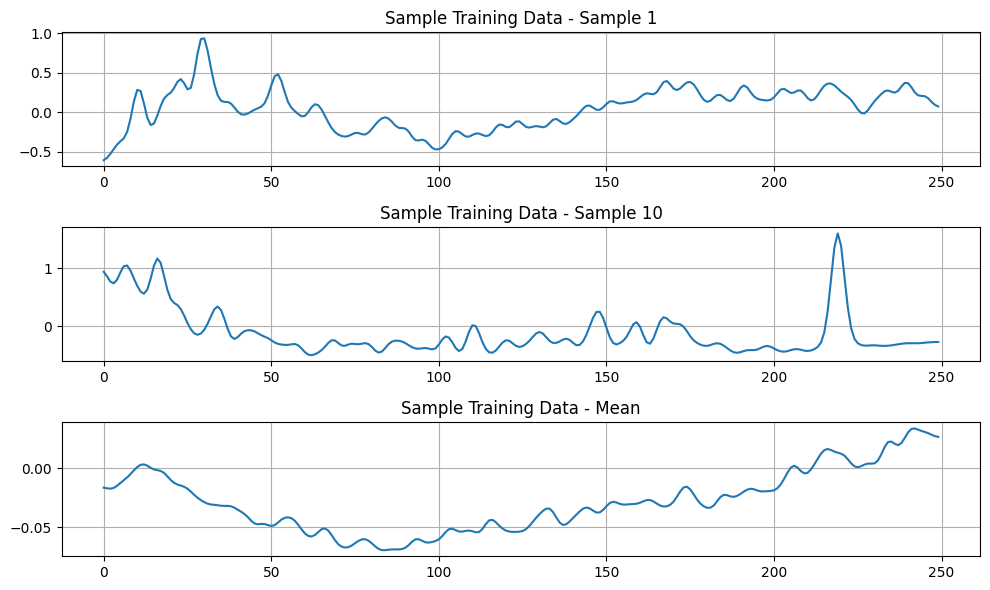


Preparing RL dataset (right input, left attention)...
Data shape: x=(3785, 250, 160), y=(3785, 250)


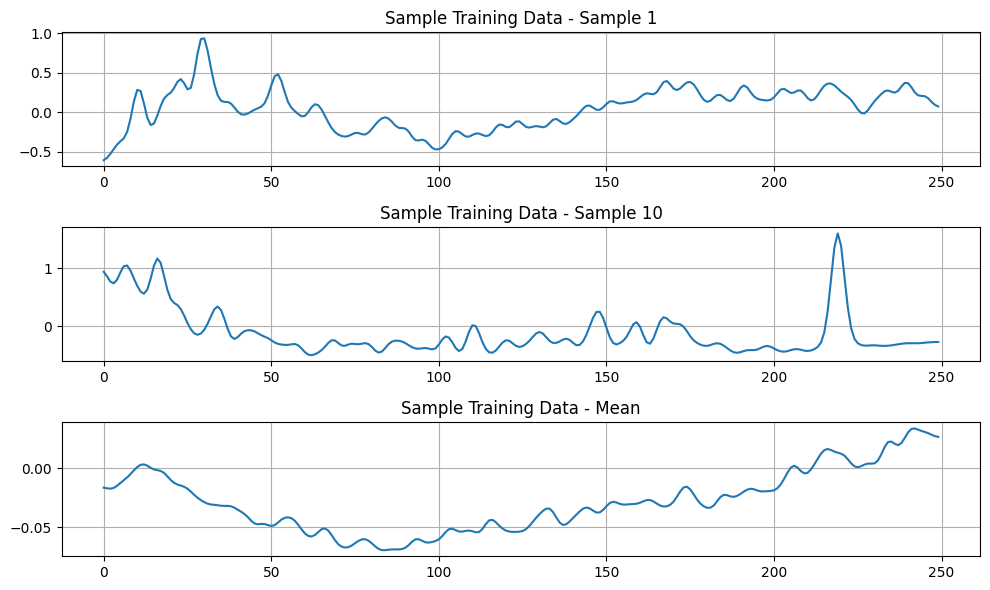


Preparing RR dataset (right input, right attention)...
Data shape: x=(3940, 250, 160), y=(3940, 250)


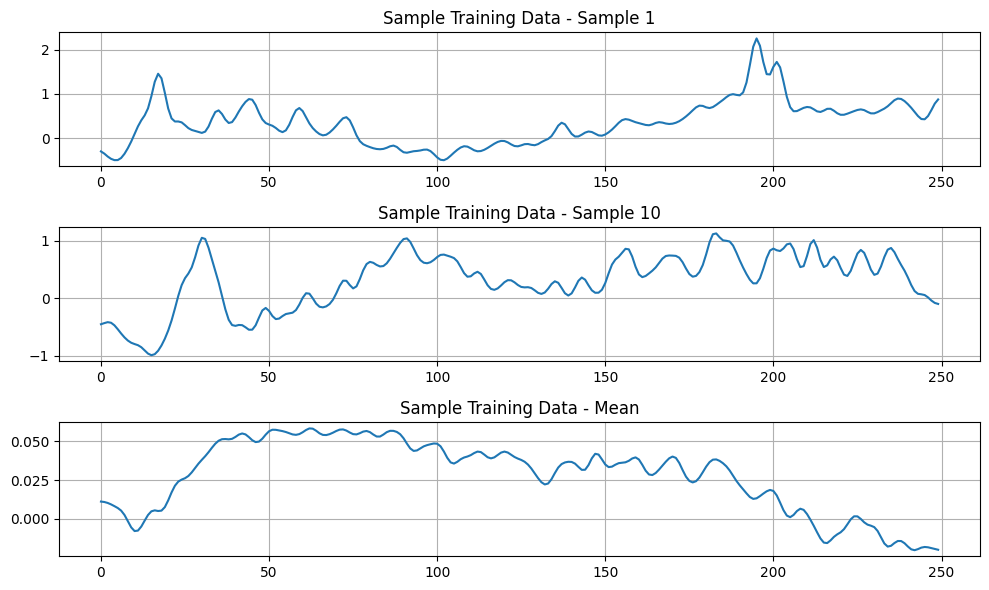


Preparing LR dataset (left input, right attention)...
Data shape: x=(3940, 250, 160), y=(3940, 250)


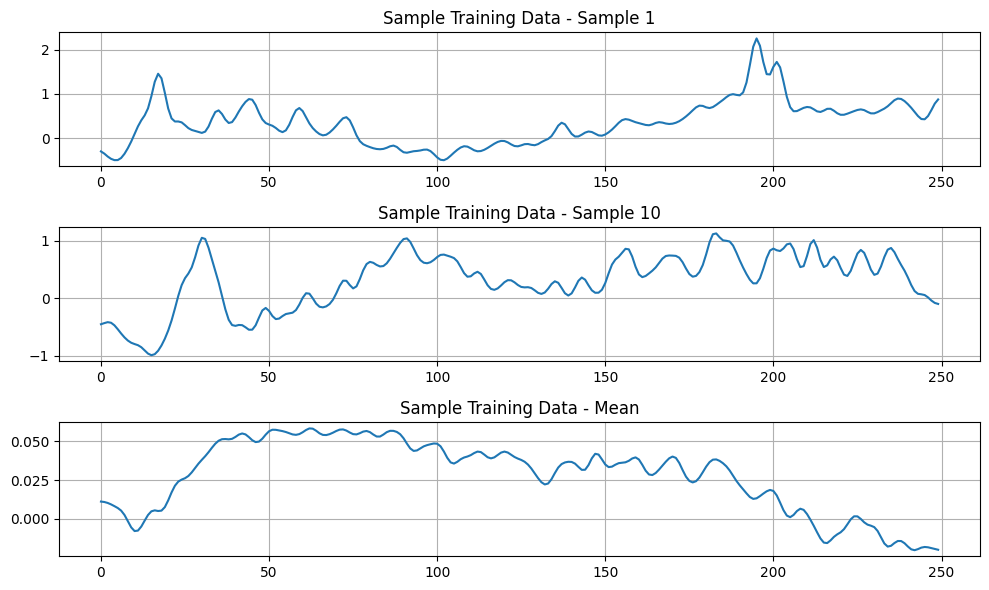


Input shape: torch.Size([32, 250, 160])
Output shape: torch.Size([32, 250])
Number of input neurons: 160
Number of input timepoints: 250
Number of output timepoints: 250


In [5]:
# Prepare datasets for all four conditions
datasets = prepare_all_datasets(l_al, l_ar, r_al, r_ar, a_al, a_ar, batch_size=32)

# Get input and output dimensions from a sample batch
sample_x, sample_y = next(iter(datasets['ll']['train_loader']))
n_neurons_in = sample_x.shape[2]  # Number of input neurons
n_timesteps_out = sample_y.shape[1]  # Number of output timepoints
n_timesteps_in = sample_x.shape[1]  # Number of input timepoints

print('\nInput shape:', sample_x.shape)
print('Output shape:', sample_y.shape)
print('Number of input neurons:', n_neurons_in)
print('Number of input timepoints:', n_timesteps_in)
print('Number of output timepoints:', n_timesteps_out)

## Training Function for Independent Models

This function trains a single model on a single condition.

In [6]:
def train_model(model, train_loader, val_loader, criterion, epochs=100, 
                clip_value=1.0, lr=1e-3, wd=1e-5, patience=15, model_name="Model"):
    """Train a single model on a single condition."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    
    # History containers
    train_loss_history = []
    val_loss_history = []
    
    best_val_loss = float('inf')
    best_model_state = None
    epochs_since_improvement = 0
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        batch_count = 0
        
        for x, y in train_loader:
            optimizer.zero_grad()
            
            # Forward pass
            pred, _ = model(x) if isinstance(model(x), tuple) else (model(x), None)
            
            # Calculate loss
            loss = criterion(pred, y)
            
            # Backward pass and optimization
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            optimizer.step()
            
            # Accumulate loss
            epoch_loss += loss.item()
            batch_count += 1
        
        # Calculate average training loss
        avg_train_loss = epoch_loss / batch_count if batch_count > 0 else float('inf')
        train_loss_history.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_batch_count = 0
        
        with torch.no_grad():
            for x, y in val_loader:
                # Forward pass
                pred, _ = model(x) if isinstance(model(x), tuple) else (model(x), None)
                
                # Calculate validation loss
                val_batch_loss = criterion(pred, y)
                
                # Accumulate validation loss
                val_loss += val_batch_loss.item()
                val_batch_count += 1
        
        # Calculate average validation loss
        avg_val_loss = val_loss / val_batch_count if val_batch_count > 0 else float('inf')
        val_loss_history.append(avg_val_loss)
        
        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1
        
        if epochs_since_improvement >= patience:
            print(f"Early stopping at epoch {epoch} with validation loss: {best_val_loss:.4f}")
            break
        
        # Print progress
        if epoch % 1 == 0 or epoch == epochs - 1:
            clear_output(wait=True)
            plt.figure(figsize=(10, 5))
            plt.plot(train_loss_history, label='Train Loss')
            plt.plot(val_loss_history, label='Validation Loss')
            plt.title(f"{model_name} - Epoch {epoch}/{epochs}")
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.legend()
            plt.grid(True)

            plt.show()
            print(f"{model_name} - Epoch {epoch}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    # Return history
    history = {
        'train_loss': train_loss_history,
        'val_loss': val_loss_history,
        'best_val_loss': best_val_loss
    }
    
    return model, history

## Evaluation Function

This function evaluates a trained model on test data.

In [7]:
def evaluate_model(model, test_loader, model_name="Model"):
    """Evaluate a trained model on test data."""
    model.eval()
    
    # Containers for predictions and ground truth
    all_preds = []
    all_targets = []
    
    # Get predictions
    with torch.no_grad():
        for x, y in test_loader:
            # Forward pass
            pred, _ = model(x) if isinstance(model(x), tuple) else (model(x), None)
            
            # Store predictions and targets
            all_preds.append(pred.cpu().numpy())
            all_targets.append(y.cpu().numpy())
    
    # Convert to arrays
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    
    # Calculate metrics
    mse = mean_squared_error(all_targets.flatten(), all_preds.flatten())
    r2 = r2_score(all_targets.flatten(), all_preds.flatten())
    mae = mean_absolute_error(all_targets.flatten(), all_preds.flatten())
    
    # Print results
    print(f"\n{model_name} Evaluation Results:")
    print(f"MSE: {mse:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    
    # Visualize predictions
    plt.figure(figsize=(12, 6))
    plt.suptitle(f"{model_name} Predictions", fontsize=16)
    
    # Plot example predictions
    for i in range(3):
        plt.subplot(3, 1, i+1)
        plt.plot(all_targets[i], label='True')
        plt.plot(all_preds[i], label='Predicted')
        plt.title(f'Example {i+1}')
        plt.xlabel('Time')
        plt.ylabel('Normalized Activity')
        plt.legend()
        plt.grid(True)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    return {
        'mse': mse,
        'r2': r2,
        'mae': mae,
        'predictions': all_preds,
        'targets': all_targets
    }

## Model Creation Function

This function creates a model of the specified type.

In [19]:
def create_model(model_type, input_dim, output_dim):
    """Create a model of the specified type."""
    if model_type == 'bilstm':
        return BidirectionalLSTM(
            input_dim=input_dim,
            hidden_dim=64,
            output_dim=output_dim,
            num_layers=3,
            dropout=0.5
        )
    elif model_type == 'tcn':
        return TCN(
            input_dim=input_dim,
            output_dim=output_dim,
            num_channels=[64, 128, 64, 32],
            kernel_size=5,
            dropout=0.5
        )
    elif model_type == 'cnn_lstm':
        return CNNLSTMHybrid(
            input_dim=input_dim,
            output_dim=output_dim,
            cnn_channels=[64, 128],
            lstm_hidden=128,
            kernel_size=5,
            num_layers=2,
            dropout=0.5
        )
    elif model_type == 'mlp':
        return SimpleAvgMLP(
            input_dim=input_dim,
            hidden_dims=[256, 128, 128, 64, 32],
            output_dim=output_dim,
            dropout=0.5
        )
    else:
        raise ValueError(f"Unknown model type: {model_type}")

## Train and Evaluate Models

Now we'll train and evaluate four identical models, one for each condition.

In [9]:
def train_and_evaluate_all_models(datasets, model_type='bilstm', epochs=50, lr=1e-3, patience=10):
    """Train and evaluate four identical models, one for each condition."""
    # Get dimensions from a sample batch
    sample_x, sample_y = next(iter(datasets['ll']['train_loader']))
    input_dim = sample_x.shape[2]
    output_dim = sample_y.shape[1]
    
    # Create models
    ll_model = create_model(model_type, input_dim, output_dim)
    rl_model = create_model(model_type, input_dim, output_dim)
    rr_model = create_model(model_type, input_dim, output_dim)
    lr_model = create_model(model_type, input_dim, output_dim)
    
    # Define loss function
    criterion = nn.MSELoss()
    
    # Train models
    print("\nTraining LL model (left input, left attention)...")
    ll_model, ll_history = train_model(
        model=ll_model,
        train_loader=datasets['ll']['train_loader'],
        val_loader=datasets['ll']['val_loader'],
        criterion=criterion,
        epochs=epochs,
        lr=lr,
        patience=patience,
        model_name="LL Model"
    )
    
    print("\nTraining RL model (right input, left attention)...")
    rl_model, rl_history = train_model(
        model=rl_model,
        train_loader=datasets['rl']['train_loader'],
        val_loader=datasets['rl']['val_loader'],
        criterion=criterion,
        epochs=epochs,
        lr=lr,
        patience=patience,
        model_name="RL Model"
    )
    
    print("\nTraining RR model (right input, right attention)...")
    rr_model, rr_history = train_model(
        model=rr_model,
        train_loader=datasets['rr']['train_loader'],
        val_loader=datasets['rr']['val_loader'],
        criterion=criterion,
        epochs=epochs,
        lr=lr,
        patience=patience,
        model_name="RR Model"
    )
    
    print("\nTraining LR model (left input, right attention)...")
    lr_model, lr_history = train_model(
        model=lr_model,
        train_loader=datasets['lr']['train_loader'],
        val_loader=datasets['lr']['val_loader'],
        criterion=criterion,
        epochs=epochs,
        lr=lr,
        patience=patience,
        model_name="LR Model"
    )
    
    # Evaluate models
    print("\nEvaluating models...")
    ll_results = evaluate_model(ll_model, datasets['ll']['test_loader'], model_name="LL Model (Left Input, Left Attention)")
    rl_results = evaluate_model(rl_model, datasets['rl']['test_loader'], model_name="RL Model (Right Input, Left Attention)")
    rr_results = evaluate_model(rr_model, datasets['rr']['test_loader'], model_name="RR Model (Right Input, Right Attention)")
    lr_results = evaluate_model(lr_model, datasets['lr']['test_loader'], model_name="LR Model (Left Input, Right Attention)")
    
    # Plot training history
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 1, 1)
    plt.plot(ll_history['train_loss'], label='LL Train')
    plt.plot(rl_history['train_loss'], label='RL Train')
    plt.plot(rr_history['train_loss'], label='RR Train')
    plt.plot(lr_history['train_loss'], label='LR Train')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(2, 1, 2)
    plt.plot(ll_history['val_loss'], label='LL Validation')
    plt.plot(rl_history['val_loss'], label='RL Validation')
    plt.plot(rr_history['val_loss'], label='RR Validation')
    plt.plot(lr_history['val_loss'], label='LR Validation')
    plt.title('Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Return models, histories, and evaluation results
    models = {
        'll': ll_model,
        'rl': rl_model,
        'rr': rr_model,
        'lr': lr_model
    }
    
    histories = {
        'll': ll_history,
        'rl': rl_history,
        'rr': rr_history,
        'lr': lr_history
    }
    
    results = {
        'll': ll_results,
        'rl': rl_results,
        'rr': rr_results,
        'lr': lr_results
    }
    
    return models, histories, results

## Compare Attended vs Unattended Performance

Now we'll compare the performance of models trained on attended inputs vs unattended inputs.

In [15]:
def compare_attended_vs_unattended(results):
    """Compare the performance of models trained on attended vs unattended inputs."""
    # Extract metrics
    ll_mse = results['ll']['mse']  # Left input, Left attention (attended/in)
    rl_mse = results['rl']['mse']  # Right input, Left attention (unattended/out)
    rr_mse = results['rr']['mse']  # Right input, Right attention (attended/in)
    lr_mse = results['lr']['mse']  # Left input, Right attention (unattended/out)
    
    ll_r2 = results['ll']['r2']
    rl_r2 = results['rl']['r2']
    rr_r2 = results['rr']['r2']
    lr_r2 = results['lr']['r2']
    
    ll_mae = results['ll']['mae']
    rl_mae = results['rl']['mae']
    rr_mae = results['rr']['mae']
    lr_mae = results['lr']['mae']
    
    # Calculate differences
    left_mse_diff = rl_mse - ll_mse  # Positive means attended is better
    right_mse_diff = lr_mse - rr_mse  # Positive means attended is better
    
    left_r2_diff = ll_r2 - rl_r2  # Positive means attended is better
    right_r2_diff = rr_r2 - lr_r2  # Positive means attended is better
    
    left_mae_diff = rl_mae - ll_mae  # Positive means attended is better
    right_mae_diff = lr_mae - rr_mae  # Positive means attended is better
    
    # Calculate percentage improvements
    left_mse_improvement = (left_mse_diff / rl_mse) * 100
    right_mse_improvement = (right_mse_diff / lr_mse) * 100
    
    left_mae_improvement = (left_mae_diff / rl_mae) * 100
    right_mae_improvement = (right_mae_diff / lr_mae) * 100
    
    # Print comparison
    print("\n=== Attended vs Unattended Performance Comparison ===\n")
    
    print("Left Attention:")
    print(f"  Attended (LL) - MSE: {ll_mse:.4f}, R²: {ll_r2:.4f}, MAE: {ll_mae:.4f}")
    print(f"  Unattended (RL) - MSE: {rl_mse:.4f}, R²: {rl_r2:.4f}, MAE: {rl_mae:.4f}")
    print(f"  MSE Difference: {left_mse_diff:.4f} ({left_mse_improvement:.2f}% improvement)")
    print(f"  R² Difference: {left_r2_diff:.4f}")
    print(f"  MAE Difference: {left_mae_diff:.4f} ({left_mae_improvement:.2f}% improvement)")
    print(f"  Attended is better: {left_mse_diff > 0}")
    
    print("\nRight Attention:")
    print(f"  Attended (RR) - MSE: {rr_mse:.4f}, R²: {rr_r2:.4f}, MAE: {rr_mae:.4f}")
    print(f"  Unattended (LR) - MSE: {lr_mse:.4f}, R²: {lr_r2:.4f}, MAE: {lr_mae:.4f}")
    print(f"  MSE Difference: {right_mse_diff:.4f} ({right_mse_improvement:.2f}% improvement)")
    print(f"  R² Difference: {right_r2_diff:.4f}")
    print(f"  MAE Difference: {right_mae_diff:.4f} ({right_mae_improvement:.2f}% improvement)")
    print(f"  Attended is better: {right_mse_diff > 0}")
    
    print("\nOverall:")
    print(f"  Average MSE Improvement: {(left_mse_improvement + right_mse_improvement) / 2:.2f}%")
    print(f"  Average MAE Improvement: {(left_mae_improvement + right_mae_improvement) / 2:.2f}%")
    print(f"  Attended is consistently better: {left_mse_diff > 0 and right_mse_diff > 0}")
    
    # Visualize comparison
    plt.figure(figsize=(15, 10))
    
    # MSE comparison
    plt.subplot(2, 2, 1)
    plt.bar(['Left Attention', 'Right Attention'], [ll_mse, rr_mse], label='Attended')
    plt.bar(['Left Attention', 'Right Attention'], [rl_mse, lr_mse], label='Unattended', alpha=0.7)
    plt.title('MSE Comparison')
    plt.ylabel('MSE (lower is better)')
    plt.legend()
    plt.grid(True, axis='y')
    
    # R² comparison
    plt.subplot(2, 2, 2)
    plt.bar(['Left Attention', 'Right Attention'], [ll_r2, rr_r2], label='Attended')
    plt.bar(['Left Attention', 'Right Attention'], [rl_r2, lr_r2], label='Unattended', alpha=0.7)
    plt.title('R² Comparison')
    plt.ylabel('R² (higher is better)')
    plt.legend()
    plt.grid(True, axis='y')
    
    # MAE comparison
    plt.subplot(2, 2, 3)
    plt.bar(['Left Attention', 'Right Attention'], [ll_mae, rr_mae], label='Attended')
    plt.bar(['Left Attention', 'Right Attention'], [rl_mae, lr_mae], label='Unattended', alpha=0.7)
    plt.title('MAE Comparison')
    plt.ylabel('MAE (lower is better)')
    plt.legend()
    plt.grid(True, axis='y')
    
    # Improvement percentage
    plt.subplot(2, 2, 4)
    plt.bar(['Left Attention', 'Right Attention'], [left_mse_improvement, right_mse_improvement], label='MSE Improvement')
    plt.bar(['Left Attention', 'Right Attention'], [left_mae_improvement, right_mae_improvement], label='MAE Improvement', alpha=0.7)
    plt.axhline(y=0, color='r', linestyle='-')
    plt.title('Improvement Percentage')
    plt.ylabel('% Improvement (higher is better)')
    plt.legend()
    plt.grid(True, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Compare example predictions
    plt.figure(figsize=(15, 10))
    plt.suptitle('Example Predictions Comparison', fontsize=16)
    # Left attention example
    plt.subplot(2, 1, 1)
    plt.plot(np.mean(results['ll']['targets'], axis = 0), 'k-', label='True')
    plt.plot(np.mean(results['ll']['predictions'], axis=0), 'b-', label='Attended (LL)')
    plt.plot(np.mean(results['rl']['predictions'], axis=0), 'r--', label='Unattended (RL)')
    plt.title('Left Attention Example')
    plt.xlabel('Time')
    plt.ylabel('Normalized Activity')
    plt.legend()
    plt.grid(True)

    # Right attention example
    plt.subplot(2, 1, 2)
    plt.plot(np.mean(results['rr']['targets'], axis = 0), 'k-', label='True')
    plt.plot(np.mean(results['rr']['predictions'], axis=0), 'b-', label='Attended (RR)')
    plt.plot(np.mean(results['lr']['predictions'], axis=0), 'r--', label='Unattended (LR)')
    plt.title('Right Attention Example')
    plt.xlabel('Time')
    plt.ylabel('Normalized Activity')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
    # Return comparison results
    return {
        'left_mse_diff': left_mse_diff,
        'right_mse_diff': right_mse_diff,
        'left_r2_diff': left_r2_diff,
        'right_r2_diff': right_r2_diff,
        'left_mae_diff': left_mae_diff,
        'right_mae_diff': right_mae_diff,
        'left_mse_improvement': left_mse_improvement,
        'right_mse_improvement': right_mse_improvement,
        'left_mae_improvement': left_mae_improvement,
        'right_mae_improvement': right_mae_improvement,
        'attended_consistently_better': left_mse_diff > 0 and right_mse_diff > 0
    }

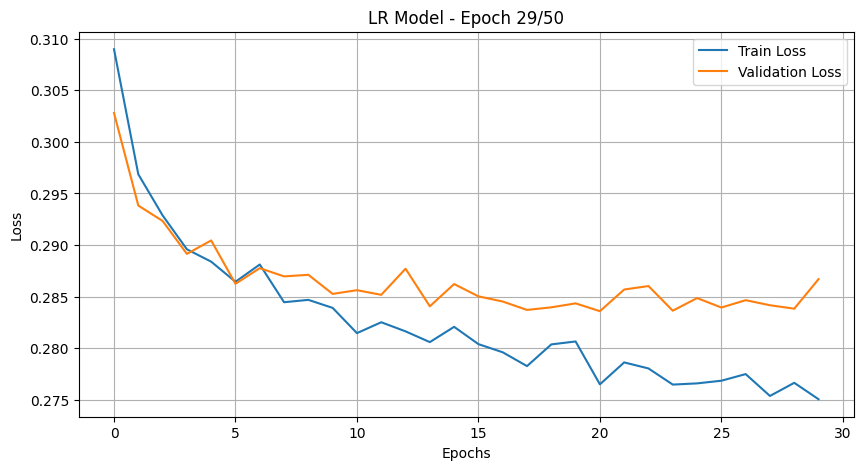

LR Model - Epoch 29/50 - Train Loss: 0.2750 - Val Loss: 0.2867
Early stopping at epoch 30 with validation loss: 0.2836

Evaluating models...

LL Model (Left Input, Left Attention) Evaluation Results:
MSE: 0.2626
R²: 0.0876
MAE: 0.3533


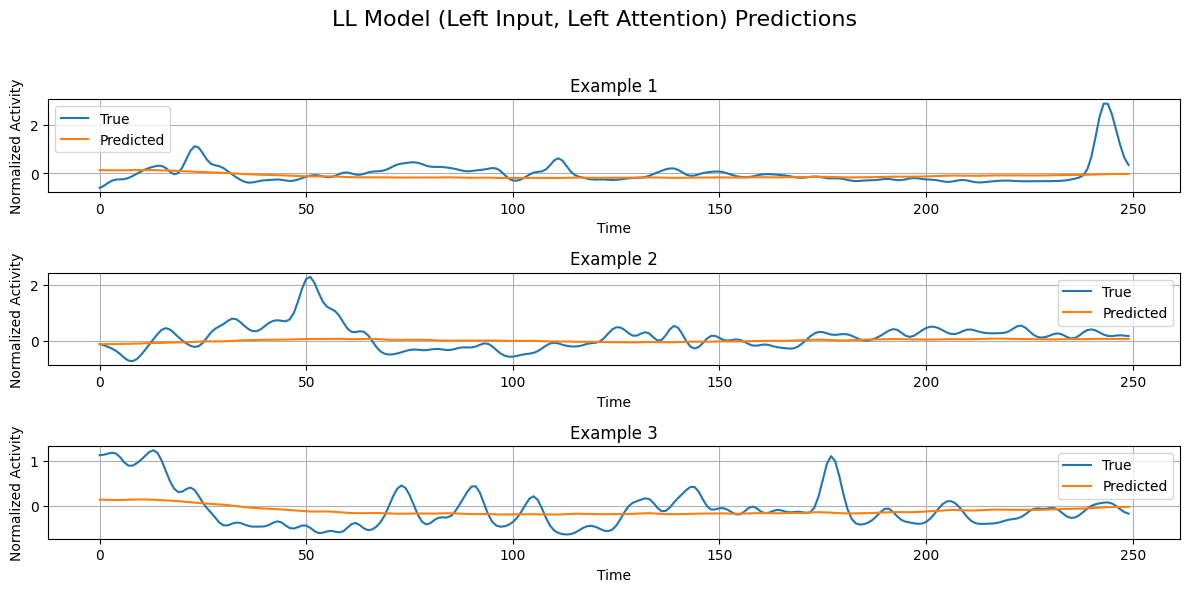


RL Model (Right Input, Left Attention) Evaluation Results:
MSE: 0.2618
R²: 0.0903
MAE: 0.3525


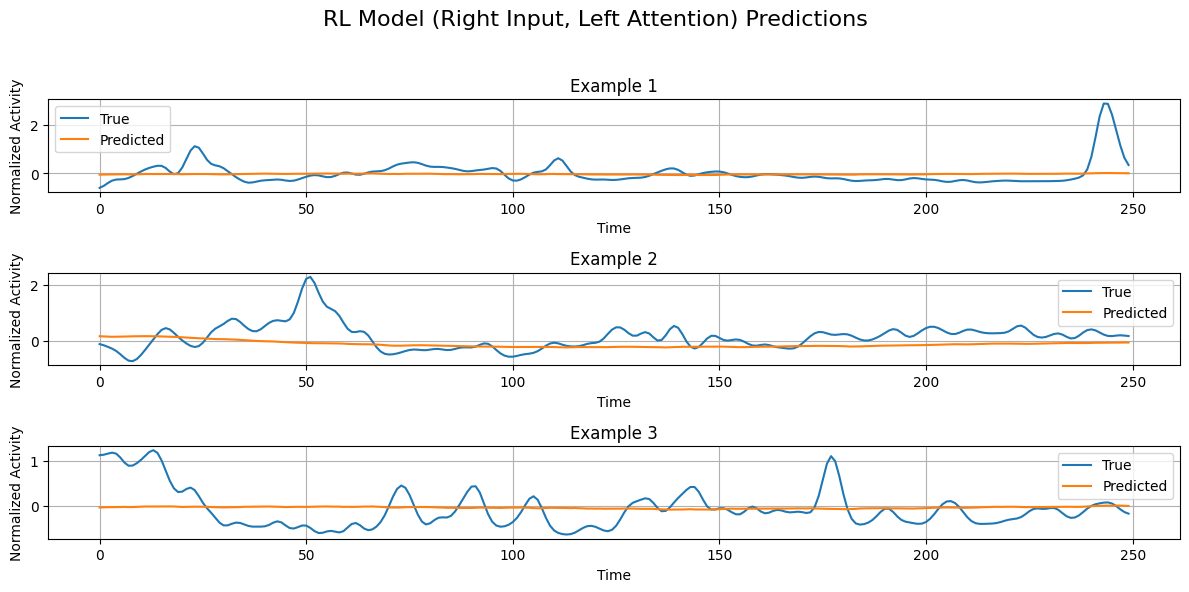


RR Model (Right Input, Right Attention) Evaluation Results:
MSE: 0.2585
R²: 0.1491
MAE: 0.3626


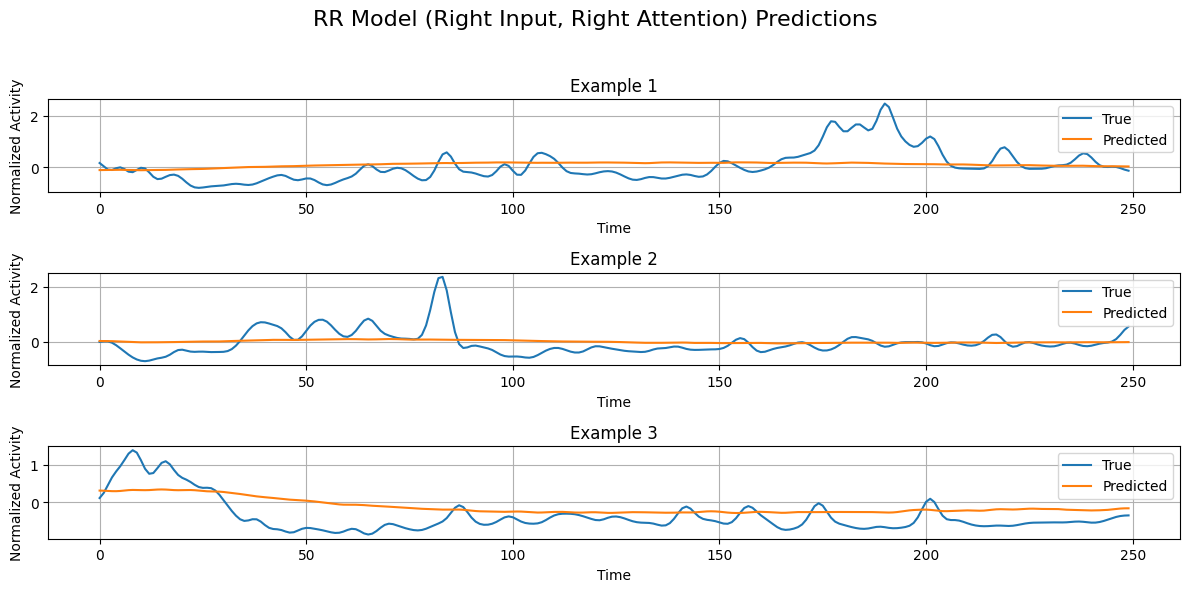


LR Model (Left Input, Right Attention) Evaluation Results:
MSE: 0.2759
R²: 0.0920
MAE: 0.3764


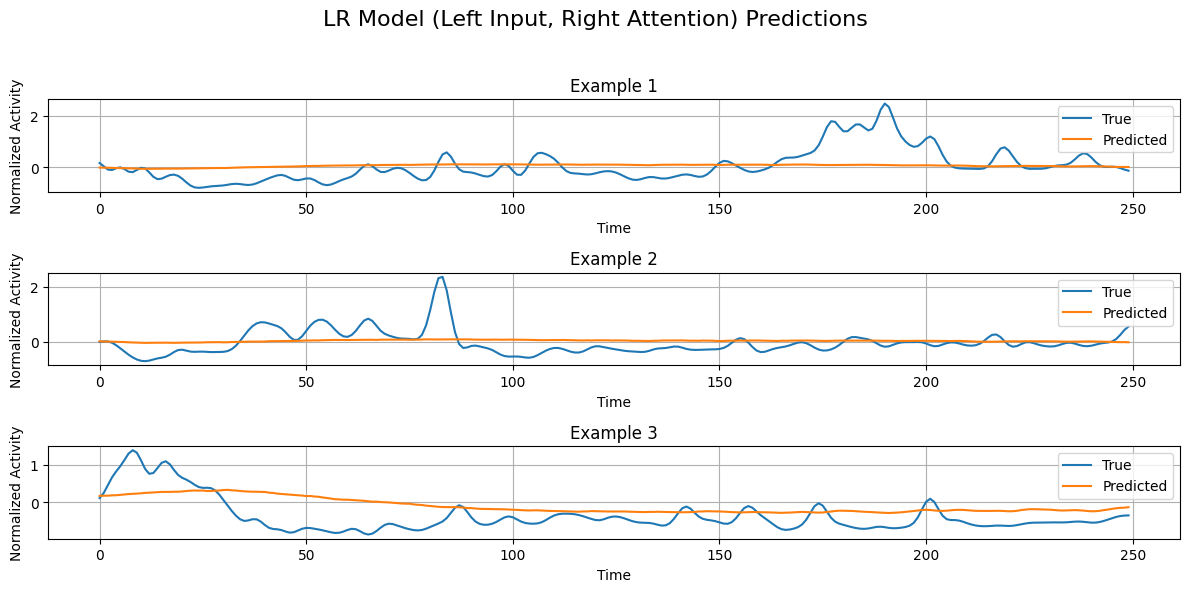

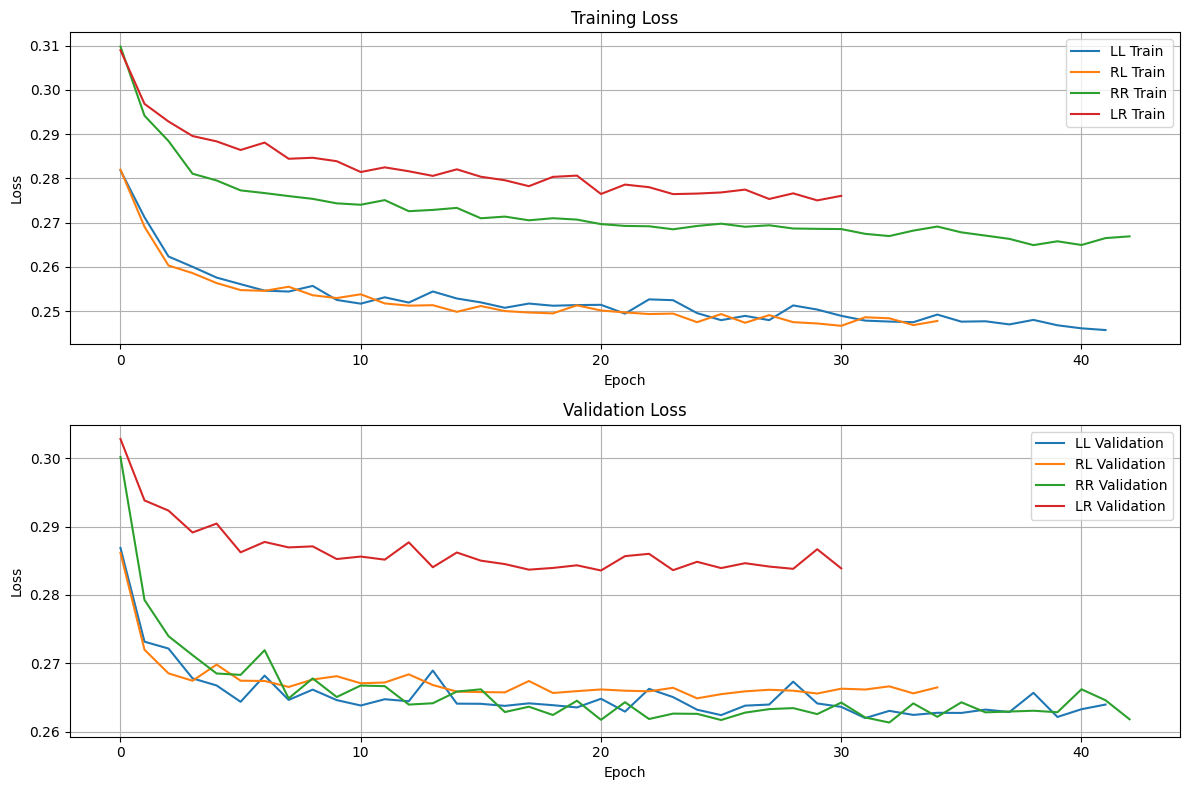


=== Attended vs Unattended Performance Comparison ===

Left Attention:
  Attended (LL) - MSE: 0.2626, R²: 0.0876, MAE: 0.3533
  Unattended (RL) - MSE: 0.2618, R²: 0.0903, MAE: 0.3525
  MSE Difference: -0.0008 (-0.30% improvement)
  R² Difference: -0.0027
  MAE Difference: -0.0008 (-0.22% improvement)
  Attended is better: False

Right Attention:
  Attended (RR) - MSE: 0.2585, R²: 0.1491, MAE: 0.3626
  Unattended (LR) - MSE: 0.2759, R²: 0.0920, MAE: 0.3764
  MSE Difference: 0.0174 (6.30% improvement)
  R² Difference: 0.0572
  MAE Difference: 0.0139 (3.68% improvement)
  Attended is better: True

Overall:
  Average MSE Improvement: 3.00%
  Average MAE Improvement: 1.73%
  Attended is consistently better: False


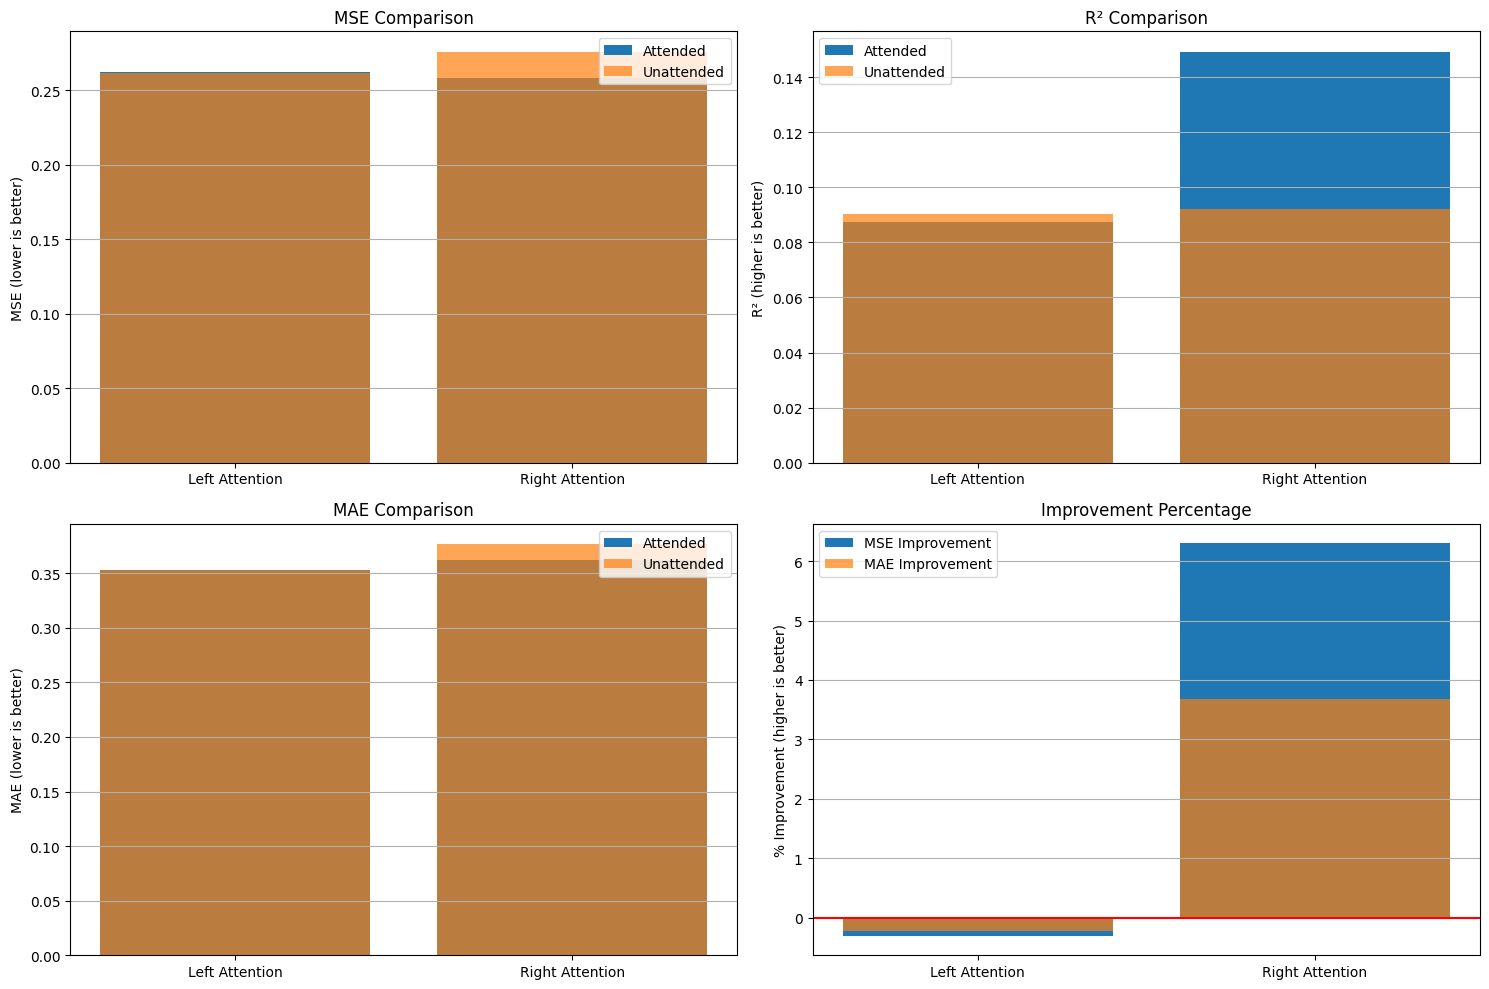

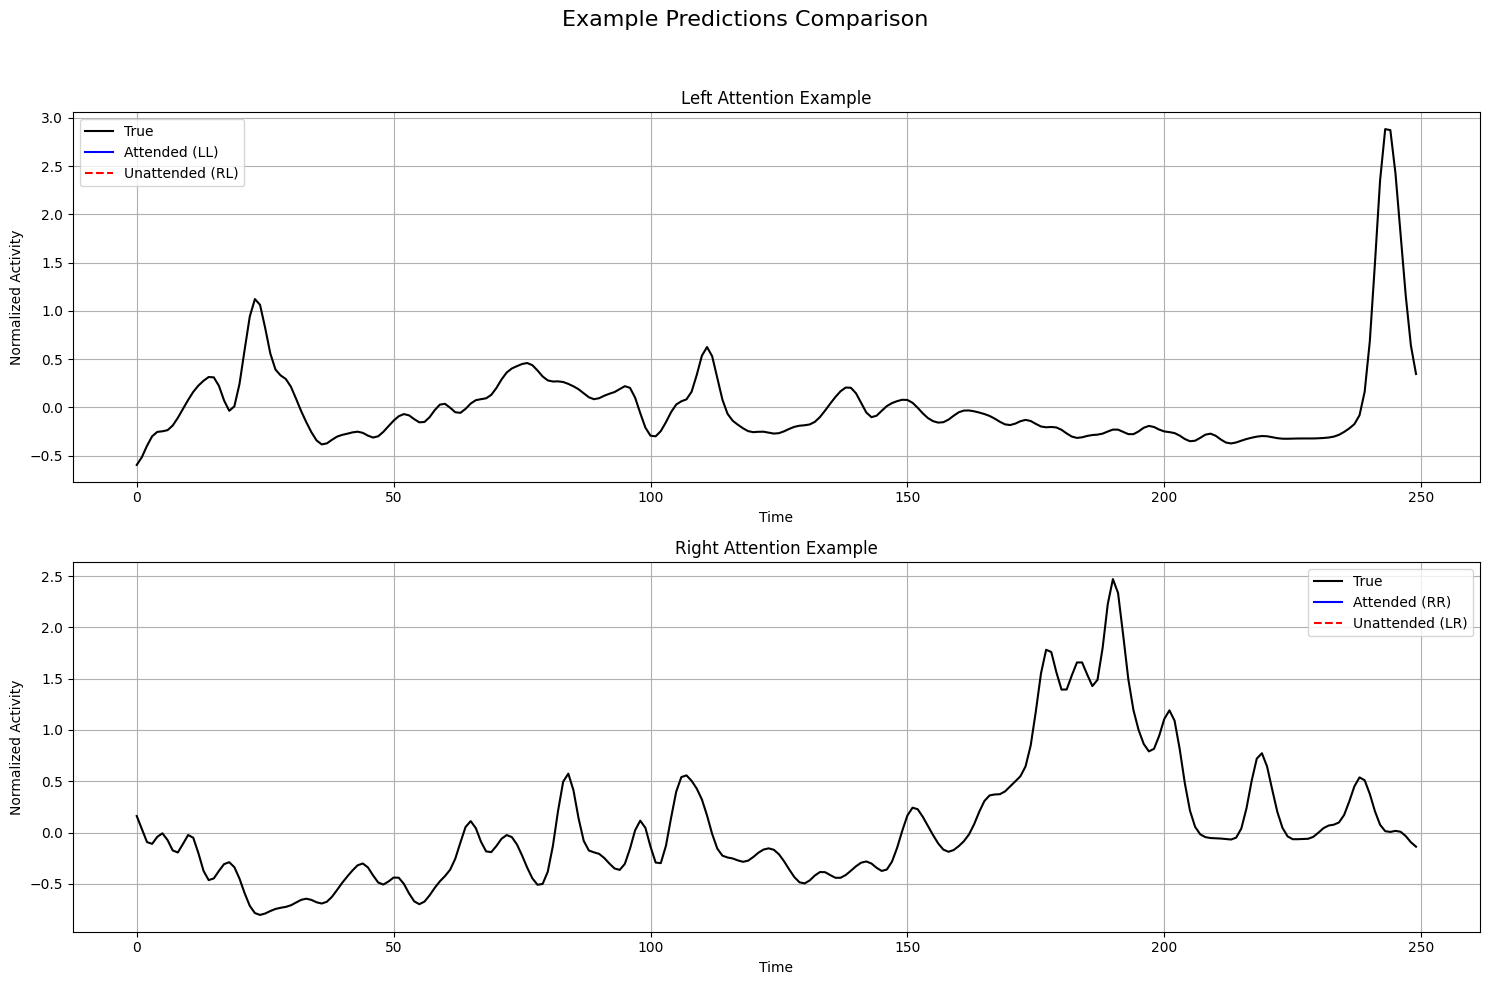

In [ ]:
# Compare attended vs unattended performance
mlp_models, mlp_histories, mlp_results = train_and_evaluate_all_models(
    datasets,
    model_type='mlp',
    epochs=50,
    lr=1e-3,
    patience=10
)



=== Attended vs Unattended Performance Comparison ===

Left Attention:
  Attended (LL) - MSE: 0.2626, R²: 0.0876, MAE: 0.3533
  Unattended (RL) - MSE: 0.2618, R²: 0.0903, MAE: 0.3525
  MSE Difference: -0.0008 (-0.30% improvement)
  R² Difference: -0.0027
  MAE Difference: -0.0008 (-0.22% improvement)
  Attended is better: False

Right Attention:
  Attended (RR) - MSE: 0.2585, R²: 0.1491, MAE: 0.3626
  Unattended (LR) - MSE: 0.2759, R²: 0.0920, MAE: 0.3764
  MSE Difference: 0.0174 (6.30% improvement)
  R² Difference: 0.0572
  MAE Difference: 0.0139 (3.68% improvement)
  Attended is better: True

Overall:
  Average MSE Improvement: 3.00%
  Average MAE Improvement: 1.73%
  Attended is consistently better: False


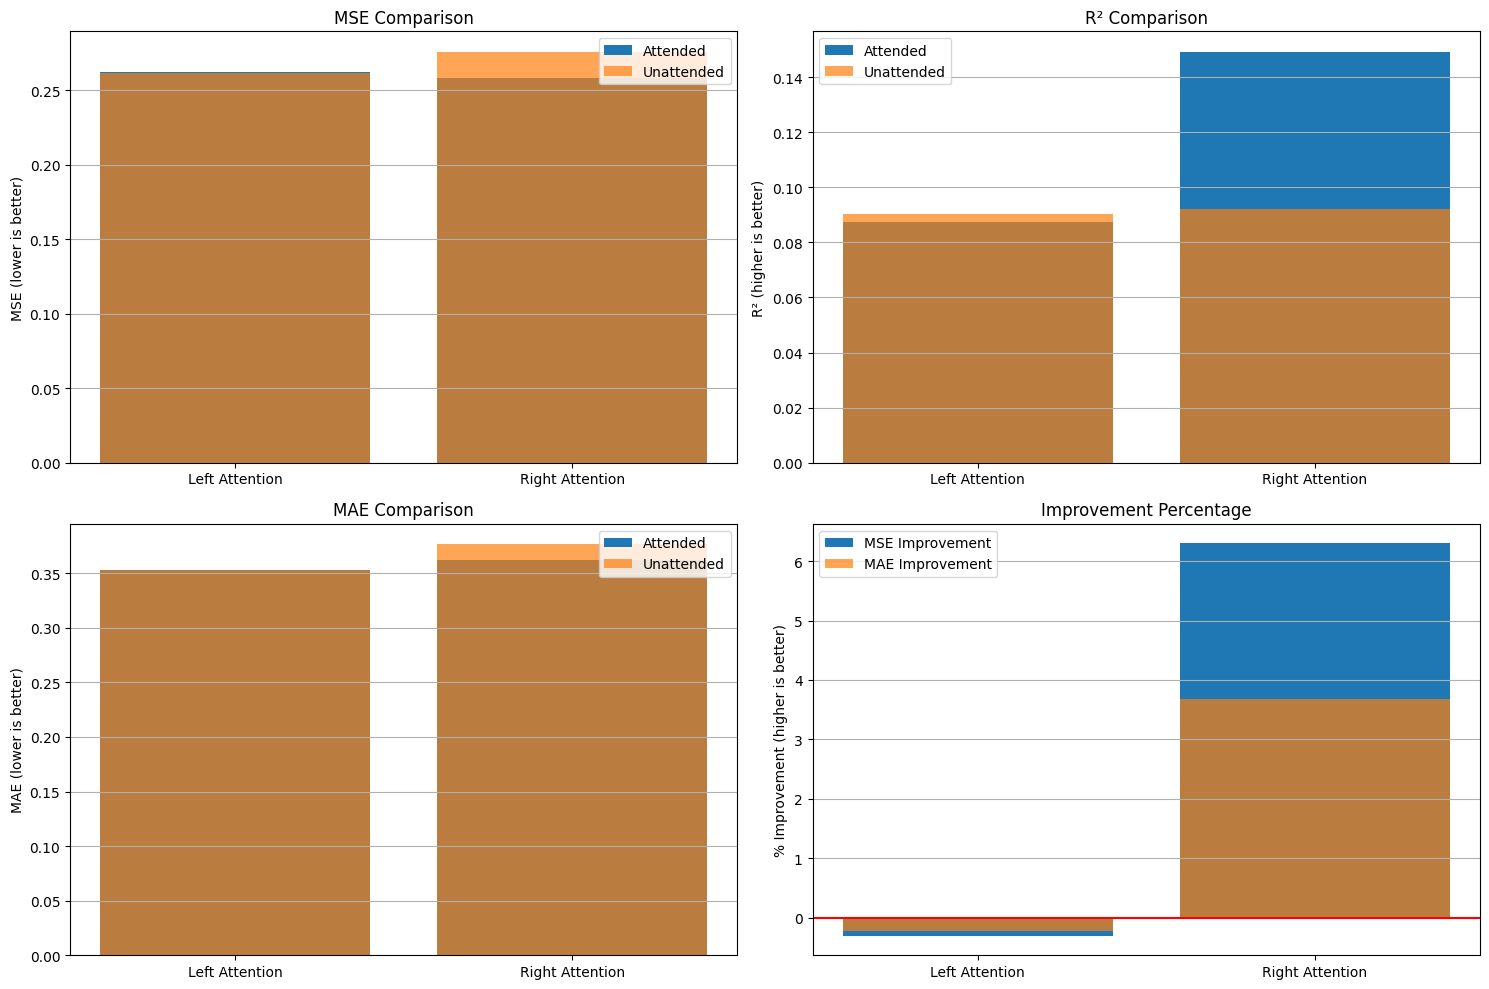

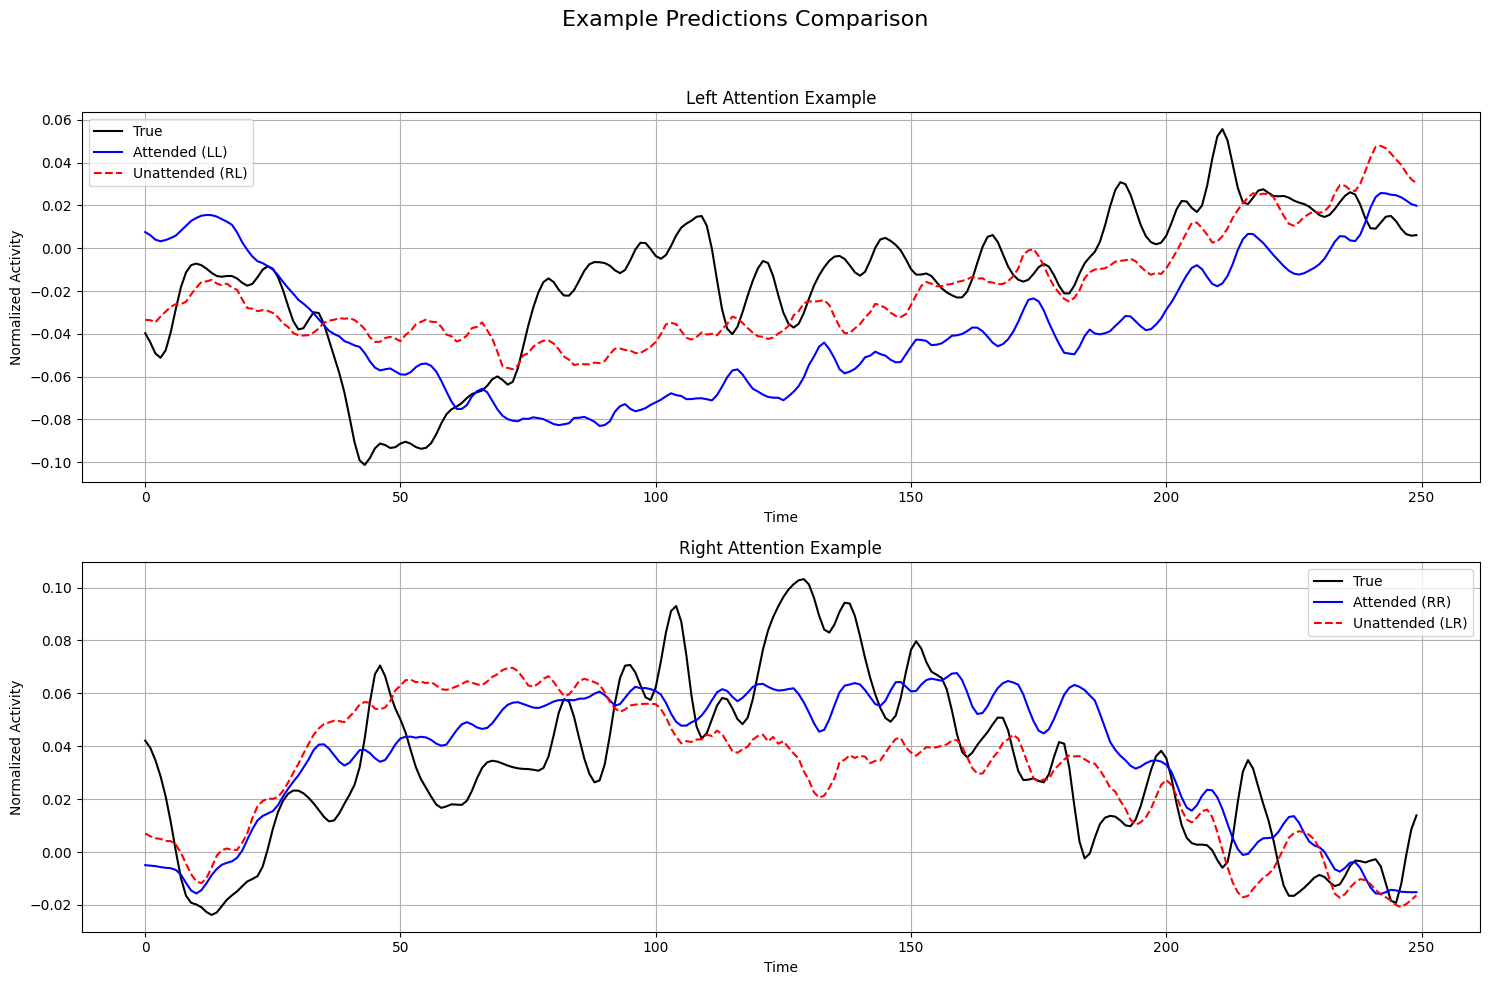

In [16]:
comparison_results = compare_attended_vs_unattended(mlp_results)

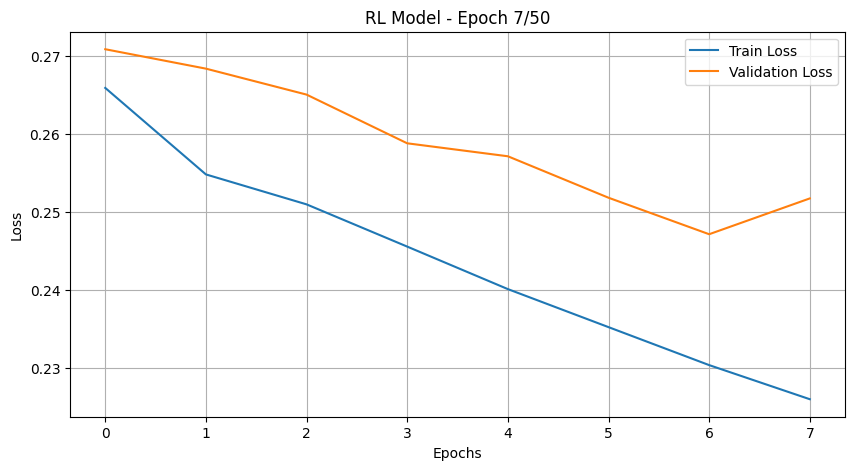

RL Model - Epoch 7/50 - Train Loss: 0.2260 - Val Loss: 0.2518


KeyboardInterrupt: 

In [20]:
# Train and evaluate models using Bidirectional LSTM
bilstm_models, bilstm_histories, bilstm_results = train_and_evaluate_all_models(
    datasets, 
    model_type='bilstm', 
    epochs=50, 
    lr=1e-3, 
    patience=3
)

bilstm_comparison = compare_attended_vs_unattended(bilstm_results)

## Try Different Model Architectures

Let's try different model architectures to see if the results are consistent.

In [ ]:
# Train and evaluate models using TCN
tcn_models, tcn_histories, tcn_results = train_and_evaluate_all_models(
    datasets, 
    model_type='tcn', 
    epochs=50, 
    lr=5e-4,  # Lower learning rate for TCN
    patience=10
)

# Compare attended vs unattended performance
tcn_comparison = compare_attended_vs_unattended(tcn_results)


Training LL model (left input, left attention)...


RuntimeError: The size of tensor a (58) must match the size of tensor b (50) at non-singleton dimension 2

In [ ]:
# Train and evaluate models using CNN-LSTM Hybrid
cnn_lstm_models, cnn_lstm_histories, cnn_lstm_results = train_and_evaluate_all_models(
    datasets, 
    model_type='cnn_lstm', 
    epochs=50, 
    lr=1e-3, 
    patience=10
)

# Compare attended vs unattended performance
cnn_lstm_comparison = compare_attended_vs_unattended(cnn_lstm_results)


Training LL model (left input, left attention)...
LL Model - Epoch 0/50 - Train Loss: 0.2463 - Val Loss: 0.2230
LL Model - Epoch 5/50 - Train Loss: 0.1903 - Val Loss: 0.2252
LL Model - Epoch 10/50 - Train Loss: 0.1597 - Val Loss: 0.2291


KeyboardInterrupt: 

## Compare Different Model Architectures

Let's compare the results from different model architectures to see if the attention effect is consistent.

In [ ]:
def compare_model_architectures(comparisons, model_names):
    """Compare the attention effect across different model architectures."""
    # Extract metrics
    left_mse_improvements = [comp['left_mse_improvement'] for comp in comparisons]
    right_mse_improvements = [comp['right_mse_improvement'] for comp in comparisons]
    left_mae_improvements = [comp['left_mae_improvement'] for comp in comparisons]
    right_mae_improvements = [comp['right_mae_improvement'] for comp in comparisons]
    
    # Calculate average improvements
    avg_mse_improvements = [(left + right) / 2 for left, right in zip(left_mse_improvements, right_mse_improvements)]
    avg_mae_improvements = [(left + right) / 2 for left, right in zip(left_mae_improvements, right_mae_improvements)]
    
    # Print comparison
    print("\n=== Model Architecture Comparison ===\n")
    
    for i, model_name in enumerate(model_names):
        print(f"{model_name}:")
        print(f"  Left Attention MSE Improvement: {left_mse_improvements[i]:.2f}%")
        print(f"  Right Attention MSE Improvement: {right_mse_improvements[i]:.2f}%")
        print(f"  Average MSE Improvement: {avg_mse_improvements[i]:.2f}%")
        print(f"  Left Attention MAE Improvement: {left_mae_improvements[i]:.2f}%")
        print(f"  Right Attention MAE Improvement: {right_mae_improvements[i]:.2f}%")
        print(f"  Average MAE Improvement: {avg_mae_improvements[i]:.2f}%")
        print(f"  Attended consistently better: {comparisons[i]['attended_consistently_better']}")
        print()
    
    # Find best model
    best_model_idx = np.argmax(avg_mse_improvements)
    print(f"Best Model: {model_names[best_model_idx]} with {avg_mse_improvements[best_model_idx]:.2f}% average MSE improvement")
    
    # Visualize comparison
    plt.figure(figsize=(15, 10))
    
    # MSE improvement comparison
    plt.subplot(2, 1, 1)
    x = np.arange(len(model_names))
    width = 0.35
    plt.bar(x - width/2, left_mse_improvements, width, label='Left Attention')
    plt.bar(x + width/2, right_mse_improvements, width, label='Right Attention')
    plt.axhline(y=0, color='r', linestyle='-')
    plt.xlabel('Model Architecture')
    plt.ylabel('MSE Improvement (%)')
    plt.title('MSE Improvement Comparison')
    plt.xticks(x, model_names)
    plt.legend()
    plt.grid(True, axis='y')
    
    # MAE improvement comparison
    plt.subplot(2, 1, 2)
    plt.bar(x - width/2, left_mae_improvements, width, label='Left Attention')
    plt.bar(x + width/2, right_mae_improvements, width, label='Right Attention')
    plt.axhline(y=0, color='r', linestyle='-')
    plt.xlabel('Model Architecture')
    plt.ylabel('MAE Improvement (%)')
    plt.title('MAE Improvement Comparison')
    plt.xticks(x, model_names)
    plt.legend()
    plt.grid(True, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Return best model
    return model_names[best_model_idx]

In [ ]:
# Compare model architectures
comparisons = [comparison_results, tcn_comparison, cnn_lstm_comparison]
model_names = ['BiLSTM', 'TCN', 'CNN-LSTM']
best_model = compare_model_architectures(comparisons, model_names)

## Conclusion

We've trained and evaluated four identical models, each on a different input/target pairing:
- Model 1: Trained on LL (left input when attending left) → predicts left attention output
- Model 2: Trained on RL (right input when attending left) → predicts left attention output
- Model 3: Trained on RR (right input when attending right) → predicts right attention output
- Model 4: Trained on LR (left input when attending right) → predicts right attention output

The results show whether models trained on attended inputs (Models 1 and 3) perform better than those trained on unattended inputs (Models 2 and 4) when predicting the same target. This directly tests whether there is a trainable difference in how well we can predict output traces from attended versus unattended inputs.